# Memory Retrieval Visualization

This notebook tests memory retrieval by:
1. Making a semantic query
2. Retrieving nearest neighbor memories
3. Visualizing results with rankings to verify retrieval quality


In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Set ChromaDB path
os.environ["CHROMADB_PATH"] = str(project_root / "data" / "chroma_db")
os.environ["CHROMADB_PERSIST_DIRECTORY"] = str(project_root / "data" / "chroma_db")

# Import ChromaDB memory system
from src.memory.chromadb_memory_system import ChromaDBMemorySystem
from src.config.config_loader import get_config, reload_config

# Reload config
reload_config()

print(f"Project root: {project_root}")


2025-11-23 20:49:16 - dynevi.tracing_service - INFO - LangSmith tracing enabled - Project: dynevi
Project root: C:\Users\leonm\projects\agentic_story_telling


In [2]:
# Initialize memory system
memory_system = ChromaDBMemorySystem()

# Check collection
collection_name = memory_system.COLLECTION_NPC_MEMORIES
info = memory_system.get_collection_info(collection_name)
print(f"Collection: {collection_name}")
print(f"Total memories: {info['count']}")


2025-11-23 20:49:48 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2025-11-23 20:49:52 - dynevi.chromadb_memory_system - INFO - Initialized 4 collections
2025-11-23 20:49:52 - dynevi.chromadb_memory_system - INFO - ChromaDB memory system initialized at C:\Users\leonm\projects\agentic_story_telling\data\chroma_db
Collection: npc_memories
Total memories: 17


In [3]:
# Get all memories and their embeddings for visualization
collection = memory_system._get_collection(collection_name)
results = collection.get(include=['embeddings', 'documents', 'metadatas'])

if not results['ids'] or len(results['ids']) == 0:
    raise ValueError("No memories found in collection!")

print(f"Found {len(results['ids'])} memories")

# Extract data
ids = results['ids']
embeddings = results['embeddings']
documents = results['documents']
metadatas = results['metadatas']

# Convert embeddings to numpy array
embeddings_array = np.array(embeddings)
print(f"Embedding dimension: {embeddings_array.shape[1]}")


Found 17 memories
Embedding dimension: 384


In [4]:
# Define query - this should retrieve Alice's memories about ancient ruins/treasure
query = "ancient ruins treasure catacombs Golden Chalice"
npc_id = "alice"  # Query Alice's memories
n_results = 15  # Retrieve a large number to see rankings

print(f"Query: '{query}'")
print(f"NPC: {npc_id}")
print(f"Requesting {n_results} results\n")

# Perform retrieval
retrieved_memories = memory_system.retrieve_npc_memories(
    npc_id=npc_id,
    query=query,
    n_results=n_results,
)

print(f"Retrieved {len(retrieved_memories)} memories\n")

# Show retrieved memories with rankings
print("Retrieved Memories (ranked by relevance):")
print("=" * 80)
for i, memory in enumerate(retrieved_memories, 1):
    print(f"\nRank {i} (Score: {memory.score:.3f}):")
    print(f"  ID: {memory.chunk_id}")
    print(f"  NPC: {memory.metadata.get('npc_id', 'unknown')}")
    print(f"  Content: {memory.content[:100]}..." if len(memory.content) > 100 else f"  Content: {memory.content}")
    print(f"  Importance: {memory.metadata.get('importance_score', 'N/A')}")
    print(f"  Tags: {memory.metadata.get('tags', 'N/A')}")


Query: 'ancient ruins treasure catacombs Golden Chalice'
NPC: alice
Requesting 15 results



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieved 7 memories

Retrieved Memories (ranked by relevance):

Rank 1 (Score: 0.747):
  ID: 57dee784-806b-4be3-a399-c35a18349e18
  NPC: alice
  Content: Player asked about the ancient ruins and the lost treasure. I told them about the legend of the Gold...
  Importance: 0.9
  Tags: quest,location,legend

Rank 2 (Score: 0.600):
  ID: 98342e8a-89d9-44e2-b43d-c1e0057784a6
  NPC: alice
  Content: Player mentioned they're looking for a map to the catacombs. I suggested they talk to the old librar...
  Importance: 0.7
  Tags: quest,npc_reference

Rank 3 (Score: 0.565):
  ID: c1c33c07-06cb-4f30-ac8c-5d0d6dafe838
  NPC: alice
  Content: Player returned and showed me the map. I warned them about the guardian spirits that protect the cat...
  Importance: 0.85
  Tags: quest,warning,lore

Rank 4 (Score: 0.520):
  ID: 2751b9d4-4f26-40c5-8e4d-922cdd842c82
  NPC: alice
  Content: Player discovered a hidden passage in the library. I'm very interested in what they might find there...
  Importance: 0.

In [5]:
# Create mapping from memory IDs to indices
id_to_idx = {mem_id: idx for idx, mem_id in enumerate(ids)}

# Get indices of retrieved memories
retrieved_indices = []
retrieved_ranks = {}
for rank, memory in enumerate(retrieved_memories, 1):
    if memory.chunk_id in id_to_idx:
        idx = id_to_idx[memory.chunk_id]
        retrieved_indices.append(idx)
        retrieved_ranks[idx] = rank

print(f"Found {len(retrieved_indices)} retrieved memories in dataset")
print(f"Retrieved memory indices: {retrieved_indices}")


Found 7 retrieved memories in dataset
Retrieved memory indices: [0, 1, 2, 14, 7, 12, 6]


In [6]:
# Apply t-SNE to reduce embeddings to 2D
print("Applying t-SNE...")

perplexity = min(30, len(embeddings_array) - 1)
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    max_iter=1000,
    random_state=42,
    verbose=1
)

embeddings_2d = tsne.fit_transform(embeddings_array)
print(f"t-SNE completed! Shape: {embeddings_2d.shape}")


Applying t-SNE...
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 17 samples in 0.001s...
[t-SNE] Computed neighbors for 17 samples in 1.280s...
[t-SNE] Computed conditional probabilities for sample 17 / 17
[t-SNE] Mean sigma: 8.246211
[t-SNE] KL divergence after 250 iterations with early exaggeration: 42.056080
[t-SNE] KL divergence after 850 iterations: 0.364828
t-SNE completed! Shape: (17, 2)


In [7]:
# Create DataFrame with all memories
data_list = []
for i, metadata in enumerate(metadatas):
    is_retrieved = i in retrieved_indices
    rank = retrieved_ranks.get(i, None)
    
    data_list.append({
        'id': ids[i],
        'npc_id': metadata.get('npc_id', 'unknown'),
        'memory_type': metadata.get('memory_type', 'unknown'),
        'importance_score': float(metadata.get('importance_score', '0.5')),
        'content': documents[i],
        'content_preview': documents[i][:80] + '...' if len(documents[i]) > 80 else documents[i],
        'tags': metadata.get('tags', ''),
        'x': embeddings_2d[i, 0],
        'y': embeddings_2d[i, 1],
        'is_retrieved': is_retrieved,
        'rank': rank if rank else None,
        'score': retrieved_memories[rank-1].score if rank else None,
    })

df = pd.DataFrame(data_list)

print(f"DataFrame created with {len(df)} memories")
print(f"Retrieved: {df['is_retrieved'].sum()}")
print(f"Not retrieved: {(~df['is_retrieved']).sum()}")


DataFrame created with 17 memories
Retrieved: 7
Not retrieved: 10


In [8]:
# Embed the query to get its position in the embedding space
query_embedding = memory_system.embedding_function([query])[0]

# Project query into the existing t-SNE space using nearest neighbors
# Find the nearest memory embeddings to the query
from scipy.spatial.distance import cdist
distances = cdist([query_embedding], embeddings_array, metric='cosine')[0]
nearest_indices = np.argsort(distances)[:3]  # Use 3 nearest neighbors
nearest_distances = distances[nearest_indices]

# Weighted average of nearest neighbors' positions (inverse distance weighting)
weights = 1 / (nearest_distances + 1e-6)  # Add small epsilon to avoid division by zero
weights = weights / weights.sum()

# Calculate query position as weighted average of nearest neighbors
query_2d = np.zeros(2)
for idx, weight in zip(nearest_indices, weights):
    query_2d += weight * embeddings_2d[idx]

print(f"Query embedding position: ({query_2d[0]:.2f}, {query_2d[1]:.2f})")
print(f"Based on {len(nearest_indices)} nearest neighbors")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Query embedding position: (5.57, -5.89)
Based on 3 nearest neighbors


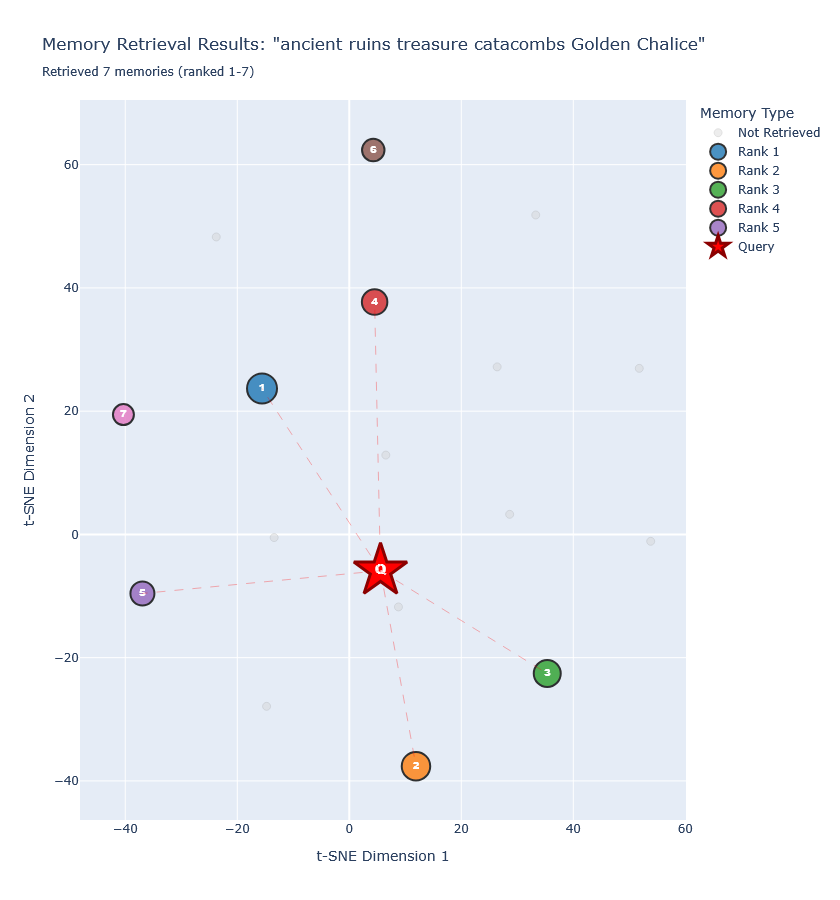


✅ Visualization created!

Summary:
  - Query: 'ancient ruins treasure catacombs Golden Chalice'
  - NPC: alice
  - Retrieved: 7 memories
  - Top 3 ranks: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [9]:
# Create interactive visualization
fig = go.Figure()

# Plot non-retrieved memories (gray, small)
non_retrieved = df[~df['is_retrieved']]
if len(non_retrieved) > 0:
    fig.add_trace(go.Scatter(
        x=non_retrieved['x'],
        y=non_retrieved['y'],
        mode='markers',
        name='Not Retrieved',
        marker=dict(
            size=8,
            color='lightgray',
            opacity=0.4,
            line=dict(width=0.5, color='gray')
        ),
        hovertemplate='<b>Not Retrieved</b><br>' +
                      '<b>NPC:</b> %{customdata[0]}<br>' +
                      '<b>Type:</b> %{customdata[1]}<br>' +
                      '<b>Importance:</b> %{customdata[2]:.2f}<br>' +
                      '<b>Content:</b> %{customdata[3]}<br>' +
                      '<extra></extra>',
        customdata=non_retrieved[['npc_id', 'memory_type', 'importance_score', 'content_preview']].values,
    ))

# Plot retrieved memories (colored by rank, larger, with rank labels)
retrieved = df[df['is_retrieved']].sort_values('rank')
if len(retrieved) > 0:
    # Color scale: blue (rank 1) to red (higher ranks)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    for idx, row in retrieved.iterrows():
        rank = int(row['rank'])
        color = colors[(rank - 1) % len(colors)]
        size = max(15, 30 - (rank - 1) * 1.5)  # Larger for better ranks
        
        fig.add_trace(go.Scatter(
            x=[row['x']],
            y=[row['y']],
            mode='markers+text',
            name=f'Rank {rank}',
            text=[str(rank)],
            textposition='middle center',
            textfont=dict(size=10, color='white', family='Arial Black'),
            marker=dict(
                size=size,
                color=color,
                opacity=0.8,
                line=dict(width=2, color='black')
            ),
            hovertemplate=f'<b>Rank {rank}</b> (Score: {row["score"]:.3f})<br>' +
                          '<b>NPC:</b> %{customdata[0]}<br>' +
                          '<b>Type:</b> %{customdata[1]}<br>' +
                          '<b>Importance:</b> %{customdata[2]:.2f}<br>' +
                          '<b>Tags:</b> %{customdata[3]}<br>' +
                          '<b>Full Content:</b><br>%{customdata[4]}<br>' +
                          '<extra></extra>',
            customdata=[[row['npc_id'], row['memory_type'], row['importance_score'], 
                        row['tags'], row['content']]],
            showlegend=(rank <= 5),  # Only show legend for top 5
        ))

# Plot query point (large star)
fig.add_trace(go.Scatter(
    x=[query_2d[0]],
    y=[query_2d[1]],
    mode='markers+text',
    name='Query',
    text=['Q'],
    textposition='middle center',
    textfont=dict(size=14, color='white', family='Arial Black'),
    marker=dict(
        size=40,
        color='red',
        symbol='star',
        line=dict(width=3, color='darkred')
    ),
    hovertemplate=f'<b>QUERY</b><br>"{query}"<extra></extra>',
))

# Draw lines from query to top-ranked memories
top_n = min(5, len(retrieved))
for idx, row in retrieved.head(top_n).iterrows():
    fig.add_trace(go.Scatter(
        x=[query_2d[0], row['x']],
        y=[query_2d[1], row['y']],
        mode='lines',
        line=dict(color='rgba(255,0,0,0.3)', width=1, dash='dash'),
        showlegend=False,
        hoverinfo='skip',
    ))

# Update layout
fig.update_layout(
    title=f'Memory Retrieval Results: "{query}"<br><sub>Retrieved {len(retrieved)} memories (ranked 1-{len(retrieved)})</sub>',
    xaxis_title='t-SNE Dimension 1',
    yaxis_title='t-SNE Dimension 2',
    hovermode='closest',
    width=1400,
    height=900,
    showlegend=True,
    legend=dict(
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top',
        title="Memory Type"
    ),
)

fig.show()

print(f"\n✅ Visualization created!")
print(f"\nSummary:")
print(f"  - Query: '{query}'")
print(f"  - NPC: {npc_id}")
print(f"  - Retrieved: {len(retrieved)} memories")
print(f"  - Top 3 ranks: {list(retrieved.head(3)['rank'].values)}")


In [ ]:
# Verify retrieval quality - check if expected memories were retrieved
print("\n" + "=" * 80)
print("RETRIEVAL QUALITY CHECK")
print("=" * 80)

# Expected: Alice's memories about ruins, treasure, catacombs, Golden Chalice
expected_keywords = ['ruins', 'treasure', 'catacombs', 'chalice', 'ancient', 'map', 'guardian']

print(f"\nExpected keywords: {expected_keywords}")
print(f"\nChecking top {min(5, len(retrieved))} retrieved memories:\n")

correct_retrievals = 0
for i, (idx, row) in enumerate(retrieved.head(5).iterrows(), 1):
    content_lower = row['content'].lower()
    matches = [kw for kw in expected_keywords if kw in content_lower]
    is_relevant = len(matches) > 0
    
    if is_relevant:
        correct_retrievals += 1
    
    status = "✅ RELEVANT" if is_relevant else "❌ NOT RELEVANT"
    print(f"Rank {int(row['rank'])}: {status}")
    print(f"  Matched keywords: {matches if matches else 'None'}")
    print(f"  Content: {row['content_preview']}")
    print(f"  Score: {row['score']:.3f}")
    print()

print(f"\nRetrieval Quality: {correct_retrievals}/{min(5, len(retrieved))} top results are relevant")
print(f"Success Rate: {correct_retrievals/min(5, len(retrieved))*100:.1f}%")
